CREDIT: Adapted from https://github.com/fastai/diffusion-nbs/blob/master/stable_diffusion.ipynb

# Stable Diffusion with 🤗 Diffusers


This notebook shows how to use Stable Diffusion. We use the 🤗 Hugging Face [🧨 Diffusers library](https://github.com/huggingface/diffusers).


In [ ]:
!pip install -Uq diffusers

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch
from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Using Stable Diffusion

To run Stable Diffusion, you need to be a registered user of 🤗 HuggingFace and have an API access token in your Colab secrets. If you have completed the [Lecture 11 colab](https://colab.research.google.com/drive/1jy-opjuAij2XkblIxGrUQT6kIB_sc0Ee?usp=sharing), you should be all set. Otherwise, go to that colab and follow the detailed instructions for getting an API access token for HuggingFace.

### Stable Diffusion Pipeline

[`StableDiffusionPipeline`](https://huggingface.co/docs/diffusers/main/en/api/pipelines/stable_diffusion#diffusers.StableDiffusionPipeline) is an end-to-end [diffusion inference pipeline](https://huggingface.co/docs/diffusers/main/en/api/pipelines/stable_diffusion) that allows you to start generating images with just a few lines of code.

When we say "inference" we're referring to using an existing model to generate samples (in this case, images), as opposed to "training" (or fine-tuning) models using new data.

* We use [`from_pretrained`](https://huggingface.co/docs/diffusers/main/en/api/diffusion_pipeline#diffusers.DiffusionPipeline.from_pretrained) to create the pipeline and download the pretrained weights.
* The string passed to `from_pretrained` in this case (`CompVis/stable-diffusion-v1-4`) is the repo id of a pretrained pipeline hosted on [Hugging Face Hub](https://huggingface.co/models).
* We indicate that we want to use the `fp16` (half-precision) version of the weights, and we tell `diffusers` to expect the weights in that format. This allows us to perform much faster inference with almost no discernible difference in quality.
* The weights for all the models in the pipeline will be downloaded and cached the first time you run this cell.

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4",
                                               revision="fp16",
                                               torch_dtype=torch.float16).to("cuda")

model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:335: FutureWarning: You are loading the variant fp16 from CompVis/stable-diffusion-v1-4 via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that CompVis/stable-diffusion-v1-4 currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'CompVis/stable-diffusion-v1-4 is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


We are now ready to use the pipeline to start creating images.

In [ ]:
prompt = "a photograph of an astronaut riding a horse"

  0%|          | 0/50 [00:00<?, ?it/s]

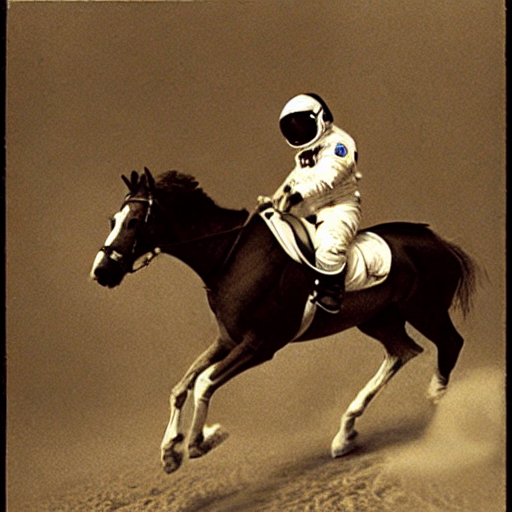

In [ ]:
torch.manual_seed(1) # set the seed for reproducibility
pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

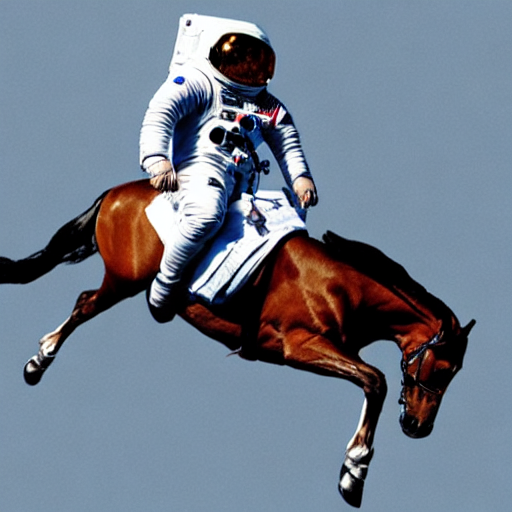

In [ ]:
torch.manual_seed(1024) # if we change the seed, we will get a different image for the same prompt
pipe(prompt).images[0]

You will have noticed that running the pipeline shows a progress bar with a certain number of steps. This is the gradual denoising approach we discussed in lecture.

Give me a prompt!

  0%|          | 0/50 [00:00<?, ?it/s]

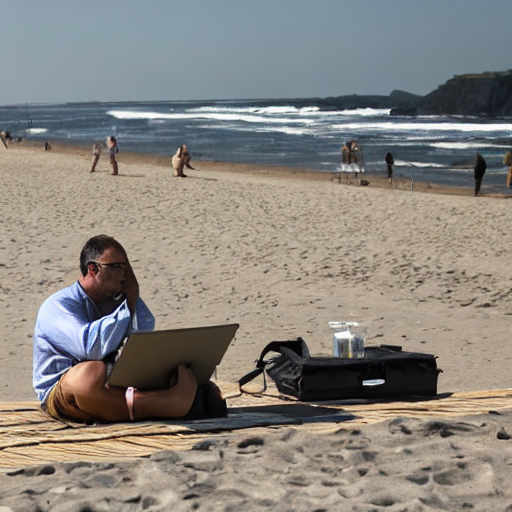

In [ ]:
torch.manual_seed(42) # set the seed for reproducibility
pipe("An MIT professor on the beach writing his lecture").images[0]

### Negative prompts

There are many extensions and variations on the basic pipeline we saw above. We will take a quick look at one of them: *Negative prompting*. Please see the source notebook (linked to at the top) for more.

_Negative prompting_ refers to the use of two prompts and "subtracting" one prompt from another.

Let's say the first prompt is "Labrador in the style of Vermeer".

  0%|          | 0/50 [00:00<?, ?it/s]

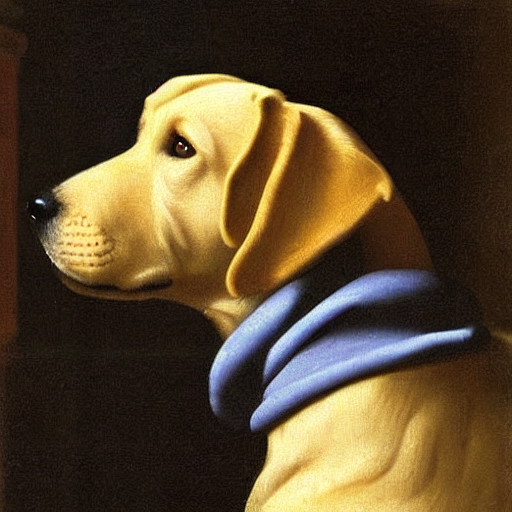

In [ ]:
torch.manual_seed(1000)
prompt = "Labrador in the style of Vermeer"
pipe(prompt).images[0]

We love the Labrador but don't care for the blue stuff.

To remove the blue stuff, we can just "subtract" the prompt "blue" from the prompt "Labrador in the style of Vermeer"(roughly speaking).

  0%|          | 0/50 [00:00<?, ?it/s]

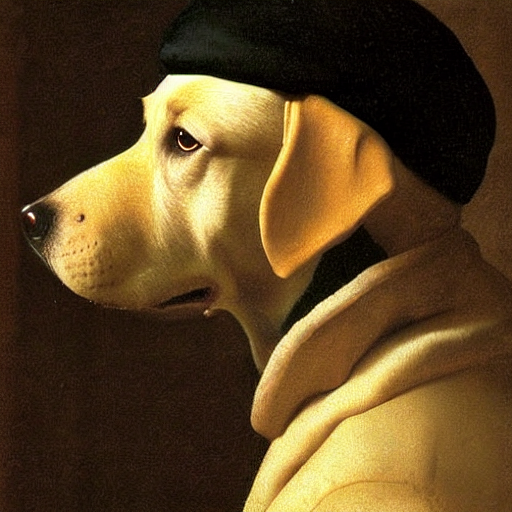

In [ ]:
torch.manual_seed(1000)
pipe(prompt, negative_prompt="blue").images[0]



---



To learn how to work with and customize diffusion models, see https://huggingface.co/docs/diffusers/main/en/tutorials/tutorial_overview.